# Opponent Exact Deck Classification EDA

Select high-coverage Exact Deck IDs from the most recent replay dates. Archetypes are explanatory labels only; they do not merge Exact Deck classes. Decks outside the exported Top K are intended to receive `valid_mask = false` in a later auxiliary task, with no `OTHER` class.

## Parameters

In [7]:
RECENT_DATE_COUNT = 10
MIN_UNIQUE_REPLAYS = 1000
TOP_K = 20
OUTPUT_NAME = 'opponent_deck_classes.csv'

## Setup and data discovery

In [8]:
from datetime import date as calendar_date
import json
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def find_project_root() -> Path:
    for candidate in (Path.cwd(), Path.cwd() / 'imitation_learning', Path.cwd().parent):
        if (candidate / 'deck' / 'analysis.py').is_file():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate the imitation_learning project root')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from deck.analysis import CardCatalog, annotate_deck_facts, load_deck_rows

DECK_DATA_DIR = PROJECT_ROOT / 'data' / 'deck'
CARD_TABLE_PATH = PROJECT_ROOT.parent / 'pokemon_tcg_ai_battle' / 'EN_Card_Data.csv'
OUTPUT_PATH = PROJECT_ROOT / 'data' / OUTPUT_NAME
DATE_FILE_PATTERN = re.compile(r'^(\d{1,2})\.(\d{1,2})\.decks\.csv$')

if RECENT_DATE_COUNT < 1 or MIN_UNIQUE_REPLAYS < 1 or TOP_K < 1:
    raise ValueError('RECENT_DATE_COUNT, MIN_UNIQUE_REPLAYS, and TOP_K must be positive')

dated_paths = []
for path in DECK_DATA_DIR.glob('*.decks.csv'):
    match = DATE_FILE_PATTERN.fullmatch(path.name)
    if match is None:
        continue
    month, day = map(int, match.groups())
    dated_paths.append((calendar_date(2001, month, day), path))
dated_paths.sort(key=lambda item: item[0])
if not dated_paths:
    raise FileNotFoundError(f'No month.day.decks.csv files found under {DECK_DATA_DIR}')
selected_sources = dated_paths[-RECENT_DATE_COUNT:]
selected_paths = [path for _, path in selected_sources]
selected_dates = [f'{value.month}.{value.day}' for value, _ in selected_sources]

print('Project root:', PROJECT_ROOT)
print('Selected dates:', ', '.join(selected_dates))
print('Output:', OUTPUT_PATH)

Project root: D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning
Selected dates: 7.29, 7.30, 7.31, 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7
Output: D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\opponent_deck_classes.csv


## Load and annotate Exact Decks

In [9]:
deck_rows = load_deck_rows(selected_paths)
catalog = CardCatalog.from_csv(CARD_TABLE_PATH)
facts = annotate_deck_facts(deck_rows, catalog)

episode_sizes = facts.groupby('replay_key').size()
if not episode_sizes.eq(2).all():
    raise ValueError('Every replay must contain exactly two deck rows')

quality = pd.DataFrame({
    'selected_dates': [len(selected_dates)],
    'participant_rows': [len(facts)],
    'unique_replays': [facts['replay_key'].nunique()],
    'unique_exact_decks': [facts['deck_id'].nunique()],
})
display(quality)
display(facts[['date', 'episode_id', 'player', 'deck_id', 'deck_archetype', 'classification_method', 'result']].head(10))

,selected_dates,participant_rows,unique_replays,unique_exact_decks
0,10,91510,45755,334


,date,episode_id,player,deck_id,deck_archetype,classification_method,result
0,7.29,88702634,0,D-C20A8A46F5C6,Marnie Grimmsnarl,rule,win
1,7.29,88702634,1,D-FBA1F87C7115,Team Rocket Mewtwo,rule,loss
2,7.29,88702649,0,D-CA60839CBA73,Crustle Wall,rule,win
3,7.29,88702649,1,D-C20A8A46F5C6,Marnie Grimmsnarl,rule,loss
4,7.29,88702651,0,D-C20A8A46F5C6,Marnie Grimmsnarl,rule,loss
5,7.29,88702651,1,D-CA60839CBA73,Crustle Wall,rule,win
6,7.29,88702653,0,D-F50FA3A23CDF,Mega Kangaskhan,rule,win
7,7.29,88702653,1,D-C20A8A46F5C6,Marnie Grimmsnarl,rule,loss
8,7.29,88702655,0,D-4BF59CA589C2,Crustle Wall,rule,loss
9,7.29,88702655,1,D-F50FA3A23CDF,Mega Kangaskhan,rule,win


## Rank eligible Exact Deck classes

`participant_occurrences` is also the number of replay-level opponent-view labels provided by that deck: every occurrence of Deck A gives the other player one Deck-A opponent label. It does not count action samples within a replay.

In [10]:
summary = (
    facts.groupby('deck_id', as_index=False)
    .agg(
        deck_archetype=('deck_archetype', 'first'),
        classification_method=('classification_method', 'first'),
        deck_card_ids=('deck_card_ids', 'first'),
        unique_replays=('replay_key', 'nunique'),
        participant_occurrences=('replay_key', 'size'),
        wins=('result', lambda values: int((values == 'win').sum())),
        losses=('result', lambda values: int((values == 'loss').sum())),
        draws=('result', lambda values: int((values == 'draw').sum())),
    )
)
summary['participant_share_percent'] = 100.0 * summary['participant_occurrences'] / len(facts)
summary['win_rate'] = summary['wins'] / summary['participant_occurrences']
summary['deck_card_ids'] = summary['deck_card_ids'].map(lambda cards: json.dumps(list(cards), separators=(',', ':')))
summary = summary.sort_values(['unique_replays', 'deck_id'], ascending=[False, True]).reset_index(drop=True)
summary.insert(0, 'overall_rank', np.arange(1, len(summary) + 1))
eligible = summary[summary['unique_replays'] >= MIN_UNIQUE_REPLAYS].copy().reset_index(drop=True)
selected = eligible.head(TOP_K).copy()
selected.insert(0, 'class_id', np.arange(len(selected), dtype=int))
selected.insert(1, 'rank', np.arange(1, len(selected) + 1))

print(f'Eligible Exact Decks: {len(eligible):,} / {len(summary):,}')
print(f'Selected classes: {len(selected):,} / requested {TOP_K:,}')
display(eligible)
display(selected)

Eligible Exact Decks: 18 / 334
Selected classes: 18 / requested 20


,overall_rank,deck_id,deck_archetype,classification_method,deck_card_ids,unique_replays,participant_occurrences,wins,losses,draws,participant_share_percent,win_rate
0,1,D-C20A8A46F5C6,Marnie Grimmsnarl,rule,"[7,7,7,7,7,7,7,7,7,7,104,104,112,112,112,112,6...",27028,33572,15881,17663,28,36.686701,0.473043
1,2,D-3F4515092DC5,Alakazam,rule,"[5,5,13,19,19,19,19,66,66,140,305,305,305,343,...",8049,8486,4187,4293,6,9.273303,0.493401
2,3,D-E2E03FE8EF95,Marnie Grimmsnarl,rule,"[7,7,7,7,7,7,7,7,7,7,104,104,112,112,112,112,6...",4275,4385,2096,2288,1,4.791826,0.477993
3,4,D-DD63244CB42C,Mega Froslass,rule,"[3,3,3,11,11,11,11,13,66,66,66,174,305,305,305...",3437,3557,2068,1487,2,3.887007,0.581389
4,5,D-E40278FD83D9,Teal Mask Ogerpon,named_fallback_main_pokemon,"[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,18,18,96,...",3024,3093,1639,1451,3,3.379958,0.529906
5,6,D-01501D644249,Mega Lopunny,named_fallback_main_pokemon,"[11,11,11,11,13,14,14,14,66,66,66,66,174,305,3...",2643,2677,1536,1135,6,2.925363,0.573777
6,7,D-C04E65DE725B,Cynthia Garchomp,rule,"[6,6,6,6,6,20,20,20,20,341,341,341,341,342,342...",2400,2422,1185,1236,1,2.646705,0.489265
7,8,D-D6C573DD89BD,Festival Lead,rule,"[1,1,1,1,1,1,1,89,89,89,89,90,90,90,90,92,92,9...",1985,1999,1036,961,2,2.184461,0.518259
8,9,D-CA60839CBA73,Crustle Wall,rule,"[1,1,11,11,11,11,14,14,14,14,18,18,18,18,20,20...",1873,1888,970,914,4,2.063162,0.513771
9,10,D-07BEDFFFBFAD,Dragapult,rule,"[2,2,2,2,5,5,5,5,7,7,112,112,119,119,119,119,1...",1619,1632,885,747,0,1.783412,0.542279


,class_id,rank,overall_rank,deck_id,deck_archetype,classification_method,deck_card_ids,unique_replays,participant_occurrences,wins,losses,draws,participant_share_percent,win_rate
0,0,1,1,D-C20A8A46F5C6,Marnie Grimmsnarl,rule,"[7,7,7,7,7,7,7,7,7,7,104,104,112,112,112,112,6...",27028,33572,15881,17663,28,36.686701,0.473043
1,1,2,2,D-3F4515092DC5,Alakazam,rule,"[5,5,13,19,19,19,19,66,66,140,305,305,305,343,...",8049,8486,4187,4293,6,9.273303,0.493401
2,2,3,3,D-E2E03FE8EF95,Marnie Grimmsnarl,rule,"[7,7,7,7,7,7,7,7,7,7,104,104,112,112,112,112,6...",4275,4385,2096,2288,1,4.791826,0.477993
3,3,4,4,D-DD63244CB42C,Mega Froslass,rule,"[3,3,3,11,11,11,11,13,66,66,66,174,305,305,305...",3437,3557,2068,1487,2,3.887007,0.581389
4,4,5,5,D-E40278FD83D9,Teal Mask Ogerpon,named_fallback_main_pokemon,"[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,18,18,96,...",3024,3093,1639,1451,3,3.379958,0.529906
5,5,6,6,D-01501D644249,Mega Lopunny,named_fallback_main_pokemon,"[11,11,11,11,13,14,14,14,66,66,66,66,174,305,3...",2643,2677,1536,1135,6,2.925363,0.573777
6,6,7,7,D-C04E65DE725B,Cynthia Garchomp,rule,"[6,6,6,6,6,20,20,20,20,341,341,341,341,342,342...",2400,2422,1185,1236,1,2.646705,0.489265
7,7,8,8,D-D6C573DD89BD,Festival Lead,rule,"[1,1,1,1,1,1,1,89,89,89,89,90,90,90,90,92,92,9...",1985,1999,1036,961,2,2.184461,0.518259
8,8,9,9,D-CA60839CBA73,Crustle Wall,rule,"[1,1,11,11,11,11,14,14,14,14,18,18,18,18,20,20...",1873,1888,970,914,4,2.063162,0.513771
9,9,10,10,D-07BEDFFFBFAD,Dragapult,rule,"[2,2,2,2,5,5,5,5,7,7,112,112,119,119,119,119,1...",1619,1632,885,747,0,1.783412,0.542279


## Auxiliary-label coverage

In [11]:
selected_ids = set(selected['deck_id'])
selected_occurrence_mask = facts['deck_id'].isin(selected_ids)
covered_replays = facts.loc[selected_occurrence_mask, 'replay_key'].nunique()
total_replays = facts['replay_key'].nunique()
covered_opponent_views = int(selected_occurrence_mask.sum())
coverage = pd.DataFrame({
    'metric': [
        'replays_with_at_least_one_selected_deck',
        'opponent_view_participants_with_valid_label',
        'opponent_view_participants_without_aux_loss',
    ],
    'count': [covered_replays, covered_opponent_views, len(facts) - covered_opponent_views],
    'percent': [
        100.0 * covered_replays / total_replays,
        100.0 * covered_opponent_views / len(facts),
        100.0 * (len(facts) - covered_opponent_views) / len(facts),
    ],
})
display(coverage)

,metric,count,percent
0,replays_with_at_least_one_selected_deck,43864,95.867118
1,opponent_view_participants_with_valid_label,73475,80.291771
2,opponent_view_participants_without_aux_loss,18035,19.708229


## Replay-count distribution

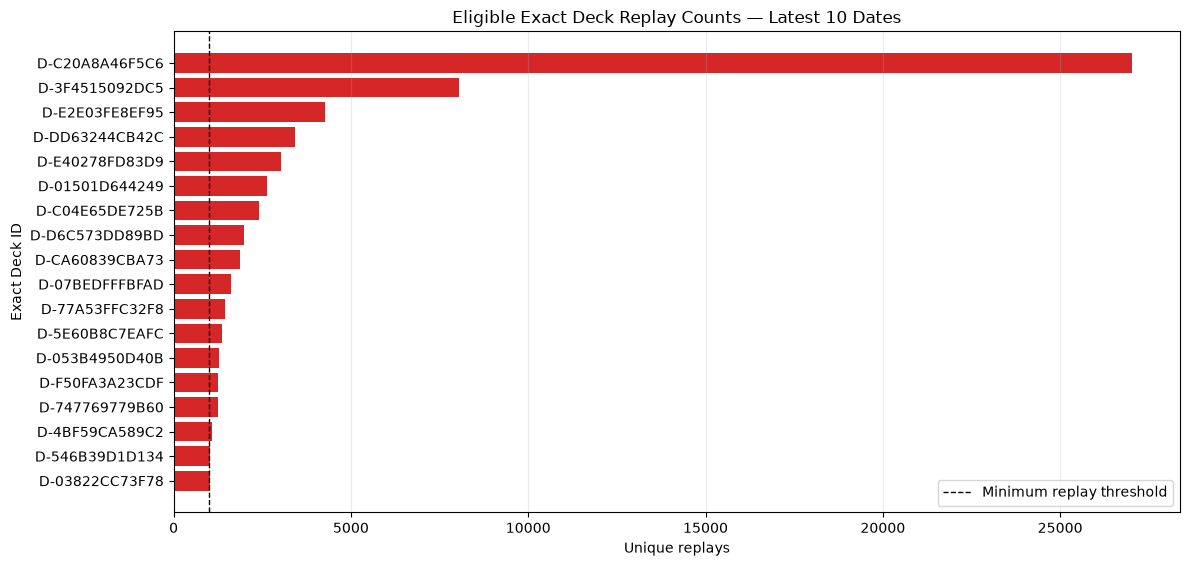

In [12]:
plot_data = eligible.sort_values('unique_replays', ascending=True).copy()
colors = np.where(plot_data['deck_id'].isin(selected_ids), '#d62728', '#7f7f7f')
fig, ax = plt.subplots(figsize=(12, max(5, 0.32 * len(plot_data))))
ax.barh(plot_data['deck_id'], plot_data['unique_replays'], color=colors)
ax.axvline(MIN_UNIQUE_REPLAYS, color='black', linestyle='--', linewidth=1, label='Minimum replay threshold')
ax.set_title(f'Eligible Exact Deck Replay Counts — Latest {len(selected_dates)} Dates')
ax.set_xlabel('Unique replays')
ax.set_ylabel('Exact Deck ID')
ax.legend()
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## Daily trend of selected classes

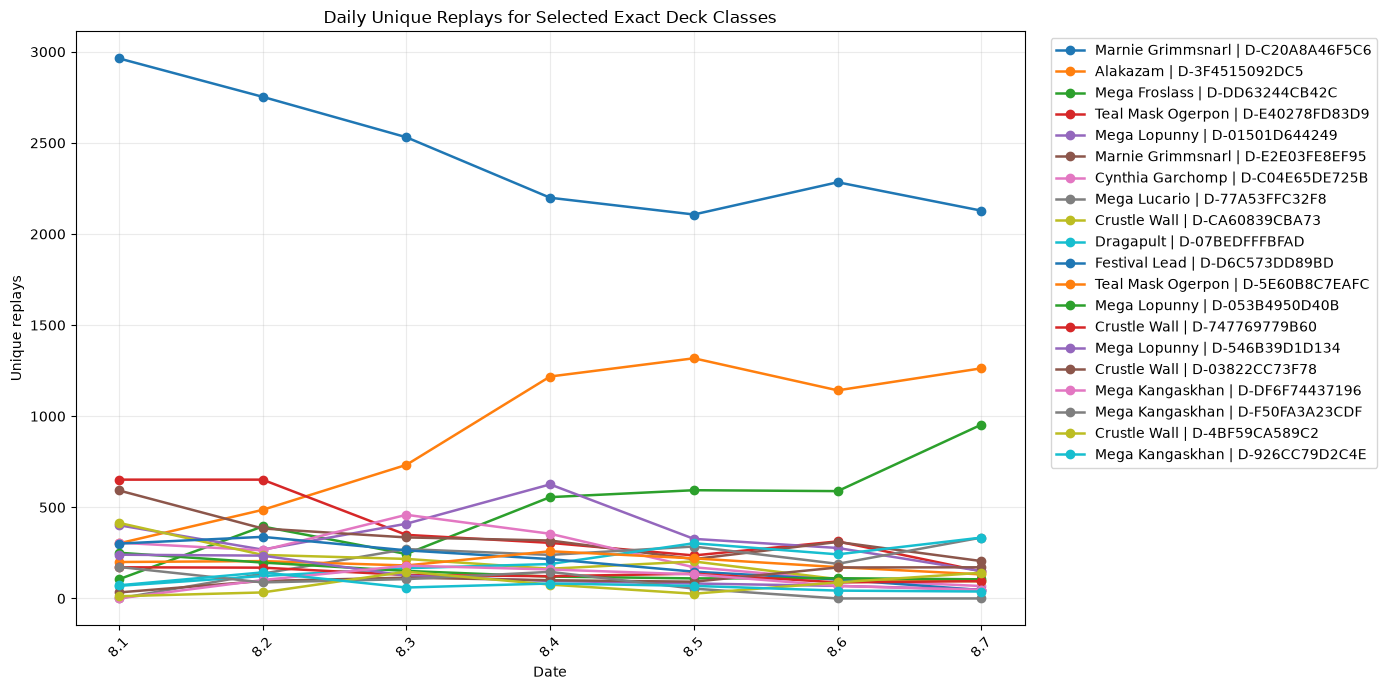

In [7]:
daily = (
    facts[facts['deck_id'].isin(selected_ids)]
    .groupby(['date', 'deck_id'])['replay_key'].nunique()
    .unstack(fill_value=0)
    .reindex(selected_dates, fill_value=0)
)
label_by_id = selected.set_index('deck_id')['deck_archetype'].to_dict()
fig, ax = plt.subplots(figsize=(14, 7))
for deck_id in selected['deck_id']:
    ax.plot(selected_dates, daily[deck_id], marker='o', linewidth=1.8, label=f"{label_by_id[deck_id]} | {deck_id}")
ax.set_title('Daily Unique Replays for Selected Exact Deck Classes')
ax.set_xlabel('Date')
ax.set_ylabel('Unique replays')
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export and integrity checks

In [13]:
export_columns = [
    'class_id', 'rank', 'deck_id', 'deck_archetype', 'classification_method',
    'unique_replays', 'participant_occurrences', 'participant_share_percent',
    'wins', 'losses', 'draws', 'win_rate', 'deck_card_ids',
]
exported = selected[export_columns].copy()
assert exported['class_id'].tolist() == list(range(len(exported)))
assert exported['deck_id'].is_unique
assert exported['unique_replays'].ge(MIN_UNIQUE_REPLAYS).all()
assert exported['deck_card_ids'].map(lambda value: len(json.loads(value)) == 60).all()
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
exported.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f'Saved {len(exported)} classes to {OUTPUT_PATH}')
display(exported)

Saved 18 classes to D:\learning\AI\Kaggle\The Pokémon Company - PTCG AI Battle Challenge Simulation\imitation_learning\data\opponent_deck_classes.csv


,class_id,rank,deck_id,deck_archetype,classification_method,unique_replays,participant_occurrences,participant_share_percent,wins,losses,draws,win_rate,deck_card_ids
0,0,1,D-C20A8A46F5C6,Marnie Grimmsnarl,rule,27028,33572,36.686701,15881,17663,28,0.473043,"[7,7,7,7,7,7,7,7,7,7,104,104,112,112,112,112,6..."
1,1,2,D-3F4515092DC5,Alakazam,rule,8049,8486,9.273303,4187,4293,6,0.493401,"[5,5,13,19,19,19,19,66,66,140,305,305,305,343,..."
2,2,3,D-E2E03FE8EF95,Marnie Grimmsnarl,rule,4275,4385,4.791826,2096,2288,1,0.477993,"[7,7,7,7,7,7,7,7,7,7,104,104,112,112,112,112,6..."
3,3,4,D-DD63244CB42C,Mega Froslass,rule,3437,3557,3.887007,2068,1487,2,0.581389,"[3,3,3,11,11,11,11,13,66,66,66,174,305,305,305..."
4,4,5,D-E40278FD83D9,Teal Mask Ogerpon,named_fallback_main_pokemon,3024,3093,3.379958,1639,1451,3,0.529906,"[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,18,18,96,..."
5,5,6,D-01501D644249,Mega Lopunny,named_fallback_main_pokemon,2643,2677,2.925363,1536,1135,6,0.573777,"[11,11,11,11,13,14,14,14,66,66,66,66,174,305,3..."
6,6,7,D-C04E65DE725B,Cynthia Garchomp,rule,2400,2422,2.646705,1185,1236,1,0.489265,"[6,6,6,6,6,20,20,20,20,341,341,341,341,342,342..."
7,7,8,D-D6C573DD89BD,Festival Lead,rule,1985,1999,2.184461,1036,961,2,0.518259,"[1,1,1,1,1,1,1,89,89,89,89,90,90,90,90,92,92,9..."
8,8,9,D-CA60839CBA73,Crustle Wall,rule,1873,1888,2.063162,970,914,4,0.513771,"[1,1,11,11,11,11,14,14,14,14,18,18,18,18,20,20..."
9,9,10,D-07BEDFFFBFAD,Dragapult,rule,1619,1632,1.783412,885,747,0,0.542279,"[2,2,2,2,5,5,5,5,7,7,112,112,119,119,119,119,1..."


## Takeaways

Use the coverage table to choose `RECENT_DATE_COUNT`, `MIN_UNIQUE_REPLAYS`, and `TOP_K`. Larger Top K increases auxiliary-label coverage but creates a harder, less balanced classification task. Decks not present in the exported CSV should be masked out of the future auxiliary loss.